In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, ConfusionMatrixDisplay)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
df = pd.read_csv('cleaned_ecommerce_churn_dataset.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (2000, 24)


,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,...,category,gender,order_amount,recency_days,frequency,monetary,tenure_days,avg_order_value,purchase_intensity,inactivity_ratio
0,ORD5000,CUST1000,39,PROD200,Canada,2021-01-07,2023-02-21,0,active,2024-08-20,...,Sports,Female,391.05,912,37,391.05,1687,10.568919,0.021932,0.540605
1,ORD5001,CUST1001,61,PROD201,USA,2020-10-19,2021-12-08,0,active,2025-07-17,...,Home,Female,512.16,1352,35,512.16,1767,14.633143,0.019808,0.765139
2,ORD5002,CUST1002,26,PROD202,Pakistan,2023-06-10,2023-09-04,3,cancelled,2025-03-12,...,Clothing,Female,1208.28,717,44,1208.28,803,27.460909,0.054795,0.892902
3,ORD5003,CUST1003,54,PROD203,India,2023-07-30,2024-02-20,4,paused,2024-09-19,...,Beauty,Male,338.64,548,1,338.64,753,338.640000,0.001328,0.727756
4,ORD5004,CUST1004,50,PROD204,India,2020-12-09,2024-09-14,0,active,2024-08-08,...,Electronics,Male,438.62,341,35,438.62,1716,12.532000,0.020396,0.198718


## Preparing data for ML

In [3]:
df['churn'] = (df['subscription_status'] == 'cancelled').astype(int)
df['churn'].value_counts(normalize=True)

churn
0    0.7535
1    0.2465
Name: proportion, dtype: float64

In [4]:
drop_cols = [
    'order_id', 'customer_id', 'product_id', 'product_name',  
    'signup_date', 'order_date', 'last_purchase_date',          
    'subscription_status',                                      
    'order_amount',                                              
    'purchase_intensity',                                        
    'inactivity_ratio',
    'churn'                                                      
]

feature_cols = [c for c in df.columns if c not in drop_cols]
print("Features used for modelling:")
print(feature_cols)

Features used for modelling:
['age', 'country', 'cancellations_count', 'unit_price', 'quantity', 'preferred_category', 'category', 'gender', 'recency_days', 'frequency', 'monetary', 'tenure_days', 'avg_order_value']


In [5]:
df[feature_cols].dtypes

age                      int64
country                 object
cancellations_count      int64
unit_price             float64
quantity                 int64
preferred_category      object
category                object
gender                  object
recency_days             int64
frequency                int64
monetary               float64
tenure_days              int64
avg_order_value        float64
dtype: object

In [6]:
df_ml = df[feature_cols + ['churn']].copy()
df_ml.head()

,age,country,cancellations_count,unit_price,quantity,preferred_category,category,gender,recency_days,frequency,monetary,tenure_days,avg_order_value,churn
0,39,Canada,0,78.21,5,Sports,Sports,Female,912,37,391.05,1687,10.568919,0
1,61,USA,0,64.02,8,Sports,Home,Female,1352,35,512.16,1767,14.633143,0
2,26,Pakistan,3,604.14,2,Electronics,Clothing,Female,717,44,1208.28,803,27.460909,1
3,54,India,4,84.66,4,Sports,Beauty,Male,548,1,338.64,753,338.640000,0
4,50,India,0,62.66,7,Sports,Electronics,Male,341,35,438.62,1716,12.532000,0


In [7]:
df_ml.describe()

,age,cancellations_count,unit_price,quantity,recency_days,frequency,monetary,tenure_days,avg_order_value,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,44.080500,2.441500,324.719460,4.948500,631.225000,25.158000,1025.845325,1286.946500,89.451780,0.246500
std,14.798091,1.702359,361.548405,2.557757,410.964947,14.158752,560.793690,313.306412,178.783706,0.431081
min,18.000000,0.000000,2.850000,1.000000,1.000000,1.000000,22.290000,732.000000,0.483830,0.000000
25%,31.000000,1.000000,111.127500,3.000000,285.000000,13.000000,551.937500,1017.000000,21.466026,0.000000
50%,45.000000,2.000000,206.515000,5.000000,586.000000,25.000000,1057.230000,1300.000000,40.039775,0.000000
75%,57.000000,4.000000,384.507500,7.000000,907.000000,37.000000,1494.682500,1558.250000,81.679940,0.000000
max,69.000000,5.000000,1991.630000,9.000000,1796.000000,49.000000,1998.080000,1827.000000,1994.700000,1.000000


In [8]:

df_ml['high_cancel_risk'] = (df_ml['cancellations_count'] >= 4).astype(int)

high_monetary  = df_ml['monetary']   > df_ml['monetary'].quantile(0.75)
high_frequency = df_ml['frequency']  > df_ml['frequency'].quantile(0.75)
df_ml['high_value_customer'] = (high_monetary & high_frequency).astype(int)

In [9]:
df_ml

,age,country,cancellations_count,unit_price,quantity,preferred_category,category,gender,recency_days,frequency,monetary,tenure_days,avg_order_value,churn,high_cancel_risk,high_value_customer
0,39,Canada,0,78.21,5,Sports,Sports,Female,912,37,391.05,1687,10.568919,0,0,0
1,61,USA,0,64.02,8,Sports,Home,Female,1352,35,512.16,1767,14.633143,0,0,0
2,26,Pakistan,3,604.14,2,Electronics,Clothing,Female,717,44,1208.28,803,27.460909,1,0,0
3,54,India,4,84.66,4,Sports,Beauty,Male,548,1,338.64,753,338.640000,0,1,0
4,50,India,0,62.66,7,Sports,Electronics,Male,341,35,438.62,1716,12.532000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,27,UK,0,30.34,7,Beauty,Clothing,Female,761,25,212.38,1502,8.495200,0,0,0
1996,59,Canada,4,381.38,3,Electronics,Home,Male,662,12,1144.14,999,95.345000,0,1,0
1997,41,India,1,305.05,6,Beauty,Beauty,Male,1102,38,1830.30,1219,48.165789,0,0,1
1998,20,USA,0,229.14,1,Beauty,Beauty,Male,249,49,229.14,1558,4.676327,0,0,0


In [10]:
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
print("Encoding:", cat_cols)

df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True).astype('int')

print(f"\nShape after encoding: {df_ml.shape}")
df_ml.head()

Encoding: ['country', 'preferred_category', 'category', 'gender']

Shape after encoding: (2000, 27)


,age,cancellations_count,unit_price,quantity,recency_days,frequency,monetary,tenure_days,avg_order_value,churn,...,preferred_category_Clothing,preferred_category_Electronics,preferred_category_Home,preferred_category_Sports,category_Clothing,category_Electronics,category_Home,category_Sports,gender_Male,gender_Other
0,39,0,78,5,912,37,391,1687,10,0,...,0,0,0,1,0,0,0,1,0,0
1,61,0,64,8,1352,35,512,1767,14,0,...,0,0,0,1,0,0,1,0,0,0
2,26,3,604,2,717,44,1208,803,27,1,...,0,1,0,0,1,0,0,0,0,0
3,54,4,84,4,548,1,338,753,338,0,...,0,0,0,1,0,0,0,0,1,0
4,50,0,62,7,341,35,438,1716,12,0,...,0,0,0,1,0,1,0,0,1,0


In [11]:
df_ml.columns

Index(['age', 'cancellations_count', 'unit_price', 'quantity', 'recency_days',
       'frequency', 'monetary', 'tenure_days', 'avg_order_value', 'churn',
       'high_cancel_risk', 'high_value_customer', 'country_Germany',
       'country_India', 'country_Pakistan', 'country_UK', 'country_USA',
       'preferred_category_Clothing', 'preferred_category_Electronics',
       'preferred_category_Home', 'preferred_category_Sports',
       'category_Clothing', 'category_Electronics', 'category_Home',
       'category_Sports', 'gender_Male', 'gender_Other'],
      dtype='object')

## Train test Split

In [12]:
X = df_ml.drop('churn', axis=1)
y = df_ml['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Churn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.1f}%")

Train size: 1600 | Test size: 400
Churn rate in train: 24.6%
Churn rate in test:  24.8%


## Scaling the data

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Create a Function to evaluate the models

In [14]:
def evaluate_model(name, model, X_te, y_te, X_tr=None, y_tr=None, cv=True):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['Active', 'Churned']))
    print(f"  AUC-ROC : {roc_auc_score(y_te, y_prob):.4f}")

    if cv and X_tr is not None:
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_f1 = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='f1').mean()
        print(f"  CV F1   : {cv_f1:.4f}")

    return {
        'Model': name,
        'Recall': round(recall_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'AUC-ROC': round(roc_auc_score(y_te, y_prob), 4)
    }

## Machine Learning

#### Logistic Regression

In [15]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_results = evaluate_model('Logistic Regression', lr, X_test_scaled, y_test, X_train_scaled, y_train)


  Logistic Regression
              precision    recall  f1-score   support

      Active       0.75      0.52      0.61       301
     Churned       0.24      0.46      0.32        99

    accuracy                           0.51       400
   macro avg       0.49      0.49      0.47       400
weighted avg       0.62      0.51      0.54       400

  AUC-ROC : 0.5107
  CV F1   : 0.3363


In [16]:
confusion_matrix(y_test, lr.predict(X_test_scaled))

array([[157, 144],
       [ 53,  46]])

#### Random Forest

In [17]:
rf = RandomForestClassifier(n_estimators=50, class_weight='balanced', 
                            random_state=42)
rf.fit(X_train, y_train)

rf_results = evaluate_model(
    'Random Forest', rf,
    X_test, y_test,
    X_train, y_train
)




  Random Forest
              precision    recall  f1-score   support

      Active       0.75      0.99      0.86       301
     Churned       0.33      0.01      0.02        99

    accuracy                           0.75       400
   macro avg       0.54      0.50      0.44       400
weighted avg       0.65      0.75      0.65       400

  AUC-ROC : 0.5367
  CV F1   : 0.0195


In [18]:
confusion_matrix(y_test, rf.predict(X_test))

array([[299,   2],
       [ 98,   1]])

#### Xgboost

In [19]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=60, scale_pos_weight=neg/pos, random_state=42, learning_rate=0.1)
xgb.fit(X_train, y_train)

xgb_results = evaluate_model(
    'XGBoost', xgb,
    X_test, y_test,
    X_train, y_train
)


  XGBoost
              precision    recall  f1-score   support

      Active       0.76      0.73      0.74       301
     Churned       0.26      0.29      0.28        99

    accuracy                           0.62       400
   macro avg       0.51      0.51      0.51       400
weighted avg       0.64      0.62      0.63       400

  AUC-ROC : 0.5391
  CV F1   : 0.2494


In [20]:
confusion_matrix(y_test, xgb.predict(X_test))

array([[220,  81],
       [ 70,  29]])

In [21]:
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.set_index('Model')
print("\nModel Comparison:")
print(results_df.to_string())


Model Comparison:
                     Recall  Precision  AUC-ROC
Model                                          
Logistic Regression  0.4646     0.2421   0.5107
Random Forest        0.0101     0.3333   0.5367
XGBoost              0.2929     0.2636   0.5391


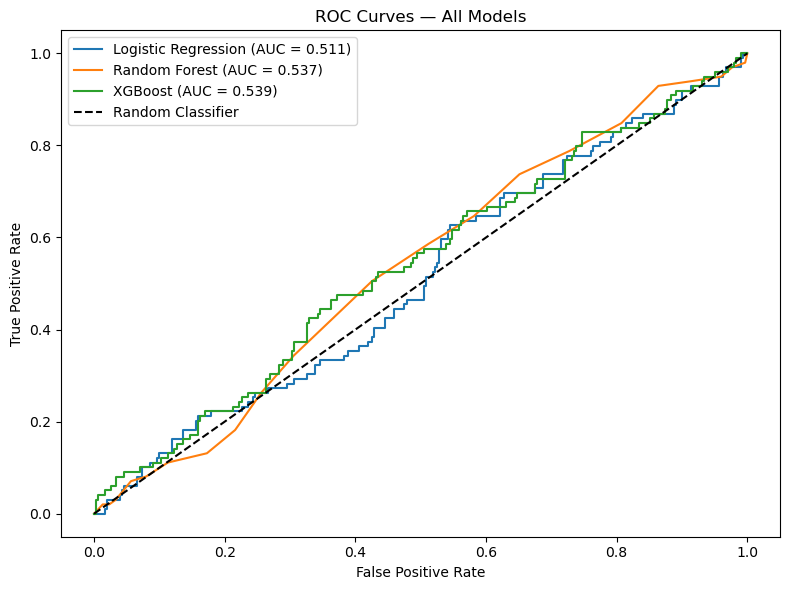

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model, X_te in [
    ('Logistic Regression', lr, X_test_scaled),
    ('Random Forest',       rf, X_test),
    ('XGBoost',             xgb, X_test)
]:
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend()
plt.tight_layout()
plt.show()

### SMOTE

In [25]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE: {0: 1206, 1: 394}
After SMOTE:  {1: 1206, 0: 1206}


#### Scaling the SMOTE Output

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

#### Modelling the SMOTE data

##### Linear Regression

In [27]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)

lr_results = evaluate_model('Logistic Regression', lr, X_test_scaled, y_test, X_train_scaled, y_train_sm)


  Logistic Regression
              precision    recall  f1-score   support

      Active       0.75      0.83      0.79       301
     Churned       0.23      0.15      0.18        99

    accuracy                           0.67       400
   macro avg       0.49      0.49      0.49       400
weighted avg       0.62      0.67      0.64       400

  AUC-ROC : 0.4607
  CV F1   : 0.7529


In [28]:
confusion_matrix(y_test, lr.predict(X_test_scaled))

array([[251,  50],
       [ 84,  15]])

#### Random Forest
* Find the best n value

In [29]:
for i in range(20,200,10):
    print(i)
    rf = RandomForestClassifier(n_estimators=i,  
                                random_state=42)
    rf.fit(X_train_sm, y_train_sm)
    print('AUC Score:', round(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]), 4))
    print('Recall:', round(recall_score(y_test, rf.predict(X_test)), 4))
    print('---------')
    

20
AUC Score: 0.5242
Recall: 0.1212
---------
30
AUC Score: 0.551
Recall: 0.101
---------
40
AUC Score: 0.5548
Recall: 0.0808
---------
50
AUC Score: 0.5642
Recall: 0.101
---------
60
AUC Score: 0.5595
Recall: 0.101
---------
70
AUC Score: 0.5606
Recall: 0.1111
---------
80
AUC Score: 0.5636
Recall: 0.101
---------
90
AUC Score: 0.5537
Recall: 0.0909
---------
100
AUC Score: 0.5545
Recall: 0.0909
---------
110
AUC Score: 0.5627
Recall: 0.0909
---------
120
AUC Score: 0.5627
Recall: 0.0909
---------
130
AUC Score: 0.5589
Recall: 0.0909
---------
140
AUC Score: 0.5622
Recall: 0.0909
---------
150
AUC Score: 0.5599
Recall: 0.0909
---------
160
AUC Score: 0.5584
Recall: 0.0909
---------
170
AUC Score: 0.5616
Recall: 0.0909
---------
180
AUC Score: 0.5539
Recall: 0.0909
---------
190
AUC Score: 0.552
Recall: 0.0909
---------


In [30]:
rf = RandomForestClassifier(n_estimators=50, #class_weight='balanced', 
                            random_state=42)
rf.fit(X_train_sm, y_train_sm)

rf_results = evaluate_model(
    'Random Forest', rf,
    X_test, y_test,
    X_train_sm, y_train_sm
)




  Random Forest
              precision    recall  f1-score   support

      Active       0.76      0.91      0.83       301
     Churned       0.28      0.10      0.15        99

    accuracy                           0.71       400
   macro avg       0.52      0.51      0.49       400
weighted avg       0.64      0.71      0.66       400

  AUC-ROC : 0.5642
  CV F1   : 0.7893


In [31]:
confusion_matrix(y_test, rf.predict(X_test))

array([[275,  26],
       [ 89,  10]])

#### XgBoost 
* Find the best n value

In [32]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

for i in range(20,200,10):
    print(i)
    xgb = XGBClassifier(n_estimators=i, scale_pos_weight=neg/pos, random_state=42, learning_rate=0.1)
    xgb.fit(X_train_sm, y_train_sm)
    
    print('AUC Score:', round(roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]), 4))
    print('Recall:', round(recall_score(y_test, xgb.predict(X_test)), 4))

    print('---------')

20
AUC Score: 0.5511
Recall: 0.6768
---------
30
AUC Score: 0.5533
Recall: 0.5657
---------
40
AUC Score: 0.5616
Recall: 0.5354
---------
50
AUC Score: 0.564
Recall: 0.5051
---------
60
AUC Score: 0.5688
Recall: 0.4747
---------
70
AUC Score: 0.5629
Recall: 0.4545
---------
80
AUC Score: 0.5635
Recall: 0.4141
---------
90
AUC Score: 0.5645
Recall: 0.4343
---------
100
AUC Score: 0.5654
Recall: 0.4242
---------
110
AUC Score: 0.5664
Recall: 0.4242
---------
120
AUC Score: 0.5654
Recall: 0.4343
---------
130
AUC Score: 0.5614
Recall: 0.4343
---------
140
AUC Score: 0.5607
Recall: 0.4141
---------
150
AUC Score: 0.5632
Recall: 0.4141
---------
160
AUC Score: 0.5657
Recall: 0.3838
---------
170
AUC Score: 0.5657
Recall: 0.404
---------
180
AUC Score: 0.5617
Recall: 0.3939
---------
190
AUC Score: 0.5619
Recall: 0.3737
---------


In [33]:
xgb = XGBClassifier(n_estimators=20, scale_pos_weight=neg/pos, random_state=42, learning_rate=0.1)
xgb.fit(X_train_sm, y_train_sm)

xgb_results = evaluate_model(
    'XGBoost', xgb,
    X_test, y_test,
    X_train_sm, y_train_sm
)


  XGBoost
              precision    recall  f1-score   support

      Active       0.78      0.39      0.52       301
     Churned       0.27      0.68      0.38        99

    accuracy                           0.46       400
   macro avg       0.52      0.53      0.45       400
weighted avg       0.66      0.46      0.48       400

  AUC-ROC : 0.5511
  CV F1   : 0.7114


In [34]:
confusion_matrix(y_test, xgb.predict(X_test))

array([[116, 185],
       [ 32,  67]])

### Evaluate Overall Performance

In [35]:
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.set_index('Model')
print("\nModel Comparison:")
print(results_df.to_string())


Model Comparison:
                     Recall  Precision  AUC-ROC
Model                                          
Logistic Regression  0.1515     0.2308   0.4607
Random Forest        0.1010     0.2778   0.5642
XGBoost              0.6768     0.2659   0.5511


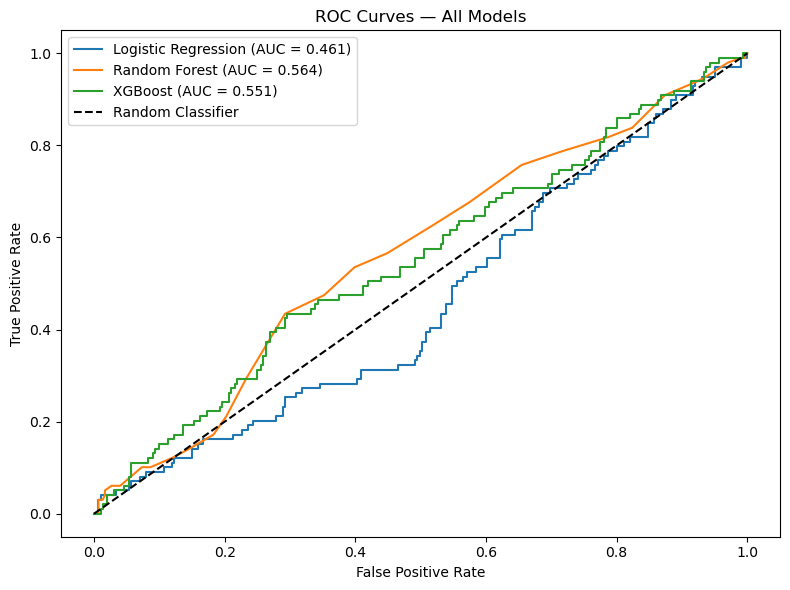

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model, X_te in [
    ('Logistic Regression', lr, X_test_scaled),
    ('Random Forest',       rf, X_test),
    ('XGBoost',             xgb, X_test)
]:
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
importances = pd.Series(xgb.feature_importances_, index=X.columns)
importances.sort_values(ascending=True)

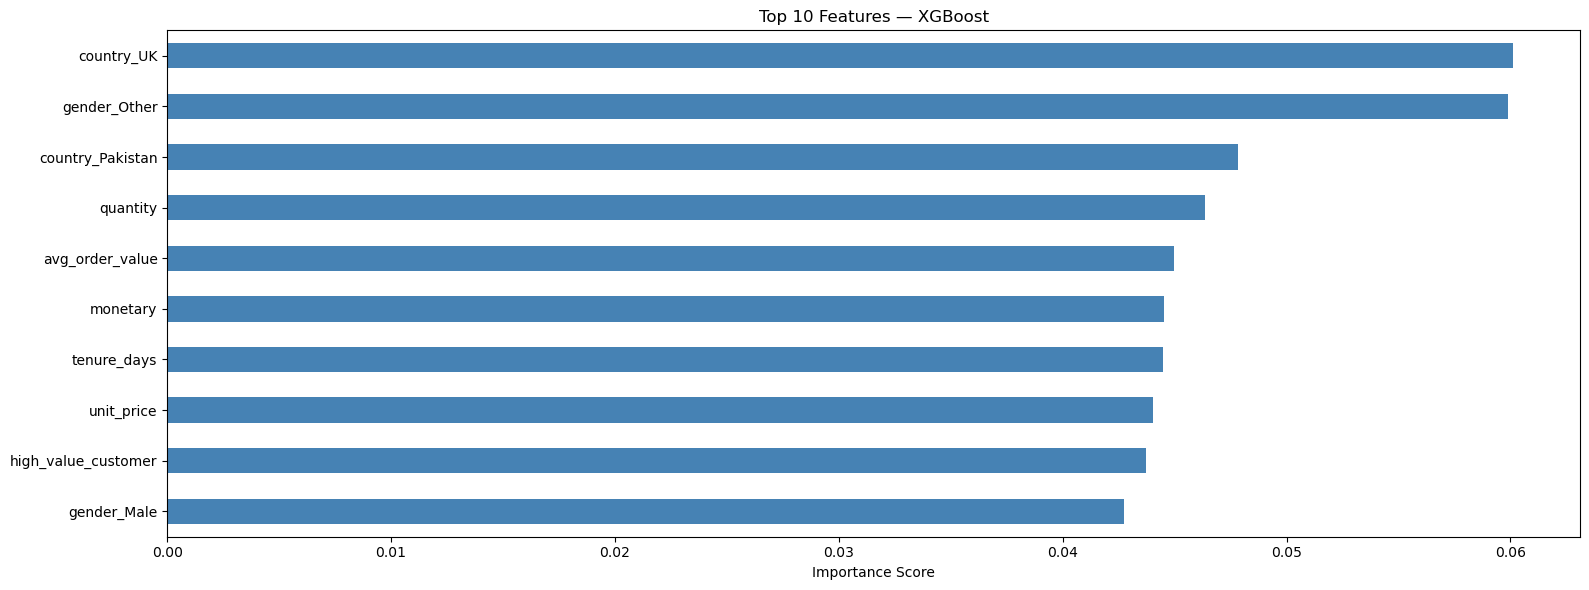

In [44]:
plt.figure(figsize=(16, 6))

importances.sort_values(ascending=True).tail(10).plot(
        kind='barh',  color='steelblue'
    )
plt.title(f'Top 10 Features — {name}')
plt.xlabel('Importance Score')

plt.tight_layout()

plt.show()